# Machine Learning Capstone — Review 1

## Air Quality Prediction using `city_day.csv`

**Review 1 scope:** Regression Track (Member 1 & Member 2 sections).

This notebook covers:
- Dataset loading and audit
- Exploratory Data Analysis (EDA)
- Data cleaning and preprocessing
- Feature engineering
- 10 required regression algorithms
- Hyperparameter tuning for 2 regression models
- Regression evaluation and visualisation
- 5-fold cross-validation for the two best regression models

**Random state:** 42

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 1. Load Dataset

In [2]:
df = pd.read_csv("city_day.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


## 2. Dataset Audit

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe(include="all").T)

Number of rows: 29531
Number of columns: 16

Data Types:


City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object


Missing Values:


City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


Duplicate Rows: 0

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
City,29531,26,Ahmedabad,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,29531,2009,2020-03-11,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PM2.5,24933.0,NaN,NaN,NaN,67.450578,64.661449,0.04,28.82,48.57,80.59,949.99
PM10,18391.0,NaN,NaN,NaN,118.127103,90.60511,0.01,56.255,95.68,149.745,1000.0
NO,25949.0,NaN,NaN,NaN,17.57473,22.785846,0.02,5.63,9.89,19.95,390.68
NO2,25946.0,NaN,NaN,NaN,28.560659,24.474746,0.01,11.75,21.69,37.62,362.21
NOx,25346.0,NaN,NaN,NaN,32.309123,31.646011,0.0,12.82,23.52,40.1275,467.63
NH3,19203.0,NaN,NaN,NaN,23.483476,25.684275,0.01,8.58,15.85,30.02,352.89
CO,27472.0,NaN,NaN,NaN,2.248598,6.962884,0.0,0.51,0.89,1.45,175.81
SO2,25677.0,NaN,NaN,NaN,14.531977,18.133775,0.01,5.67,9.16,15.22,193.86


## 3. Target Distribution

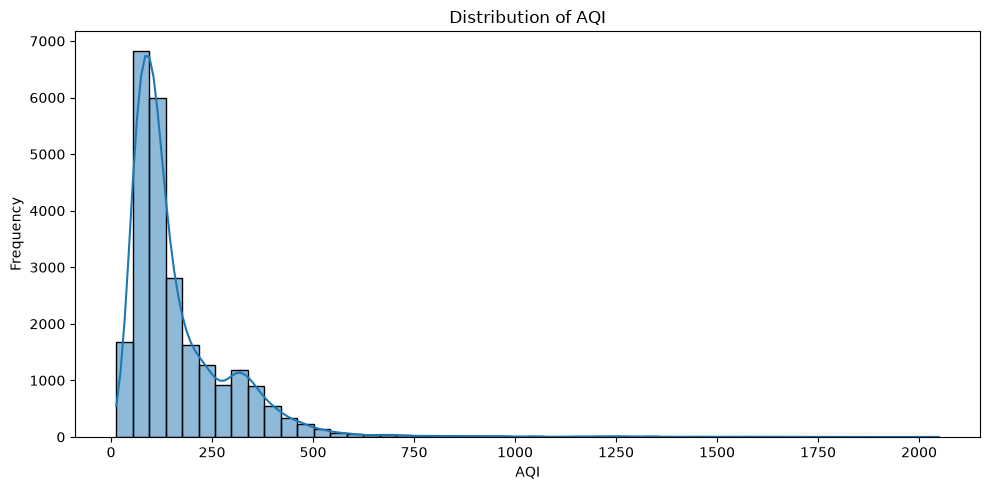

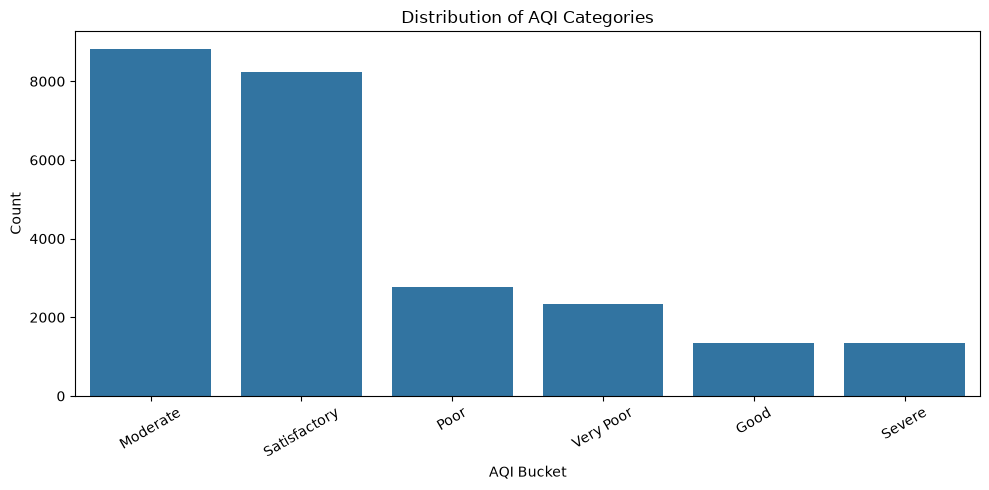

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df["AQI"], bins=50, kde=True)
plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="AQI_Bucket",
    order=df["AQI_Bucket"].value_counts().index
)
plt.title("Distribution of AQI Categories")
plt.xlabel("AQI Bucket")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 📝 Observation — Target (AQI) Distribution

AQI is strongly right-skewed: most readings sit between roughly 50-250, with a long tail out to ~2,000. The corresponding `AQI_Bucket` counts confirm this — `Moderate` (~8,800) and `Satisfactory` (~8,200) dominate, while `Severe` and `Good` each account for only ~1,300 records. This skew and the rare extreme values are important: they're the likely cause of the much lower, more volatile 5-fold CV R² seen later compared to the single train/test split (see the cross-validation observation below), since a handful of high-AQI records can land unevenly across folds. A log-transform of the target could be worth testing as a follow-up.

## 4. Exploratory Data Analysis — Feature Distributions

Numerical columns: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']


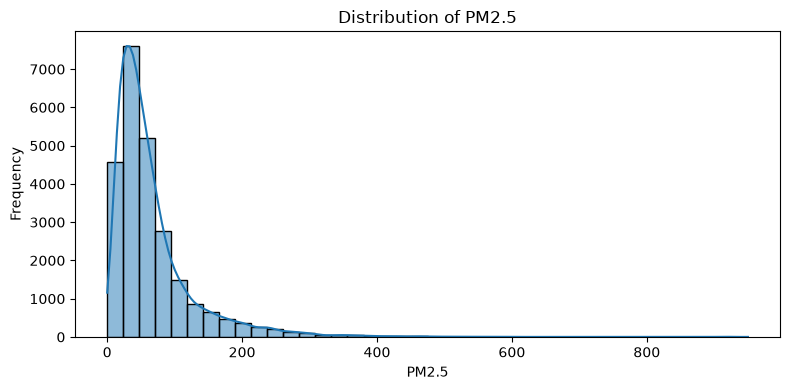

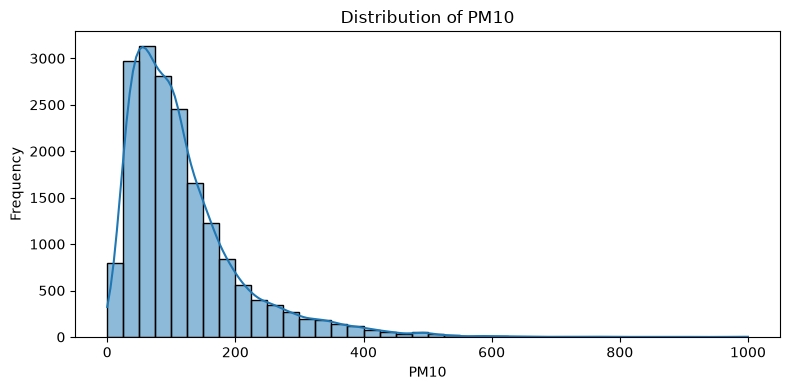

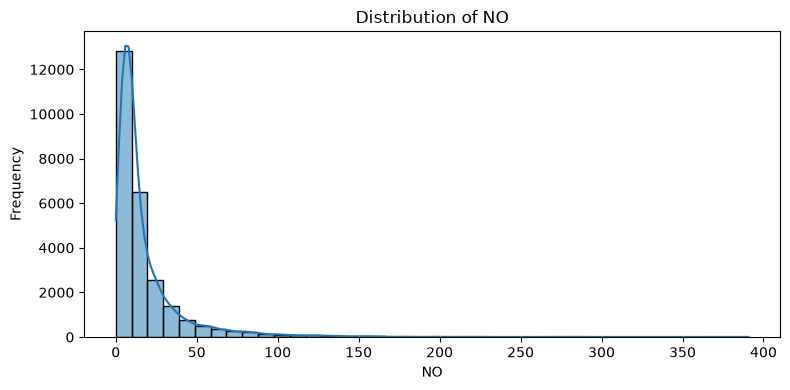

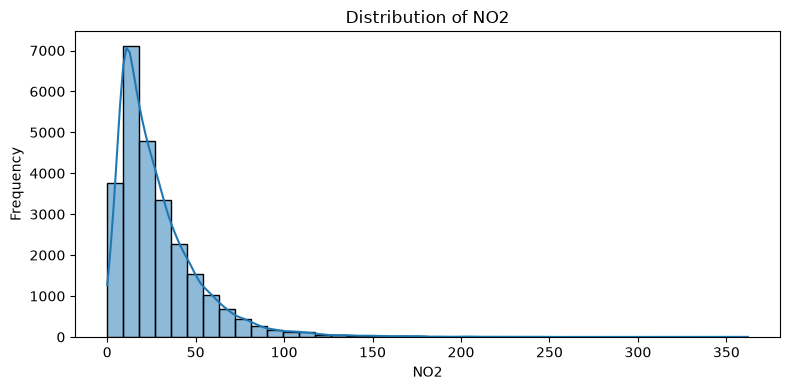

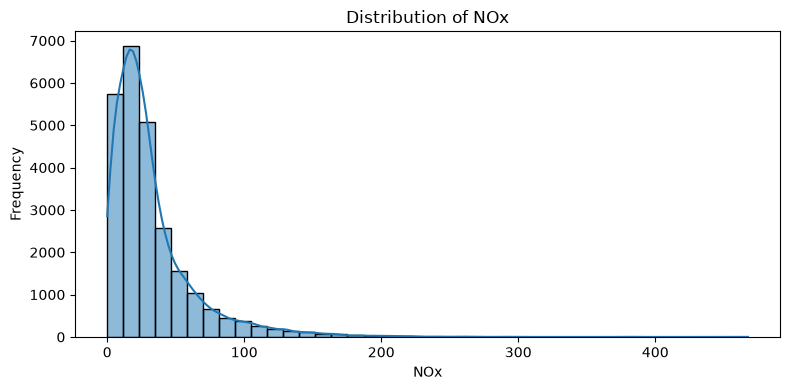

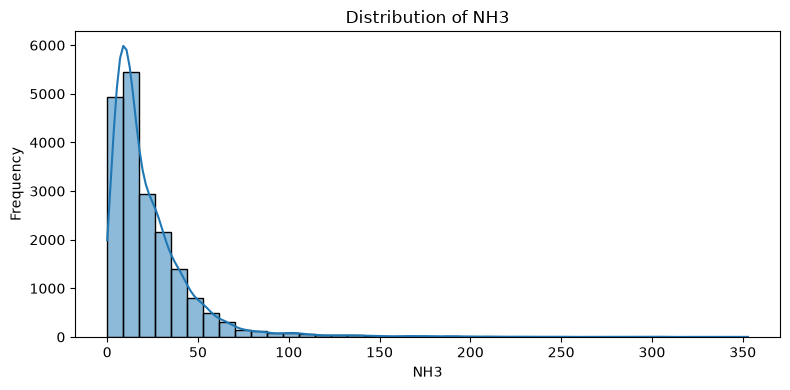

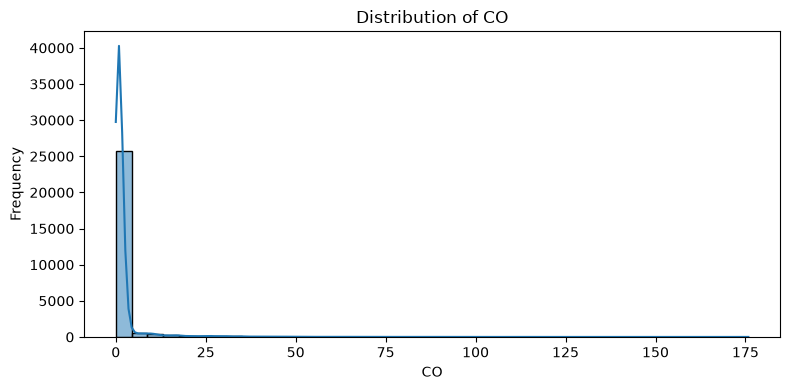

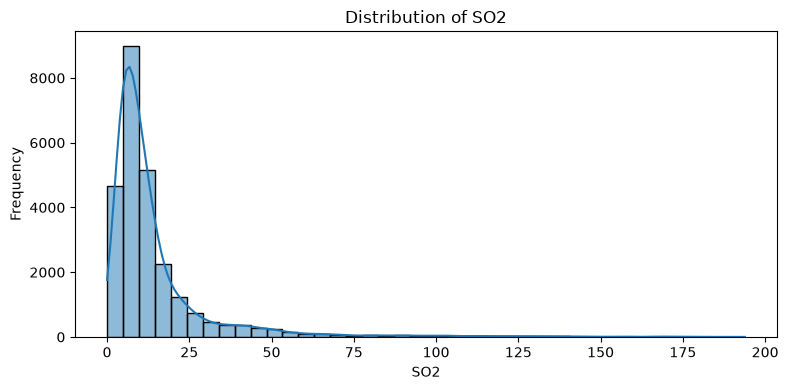

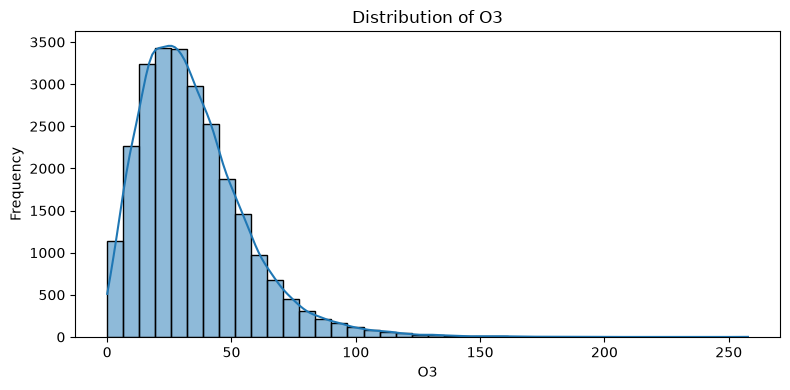

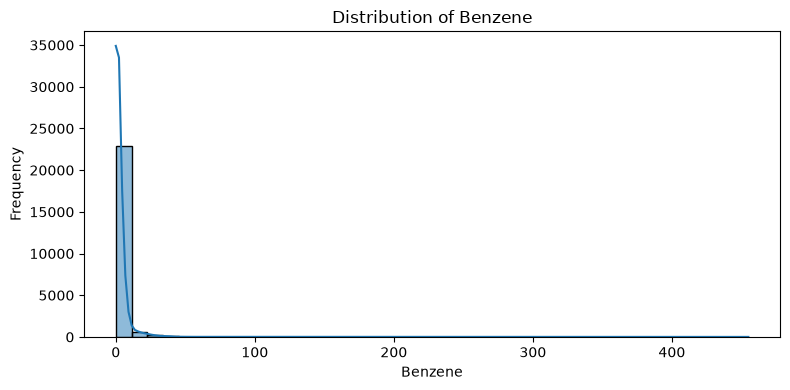

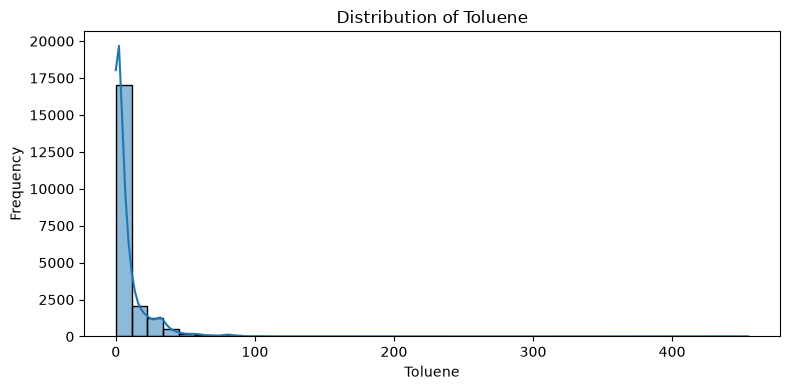

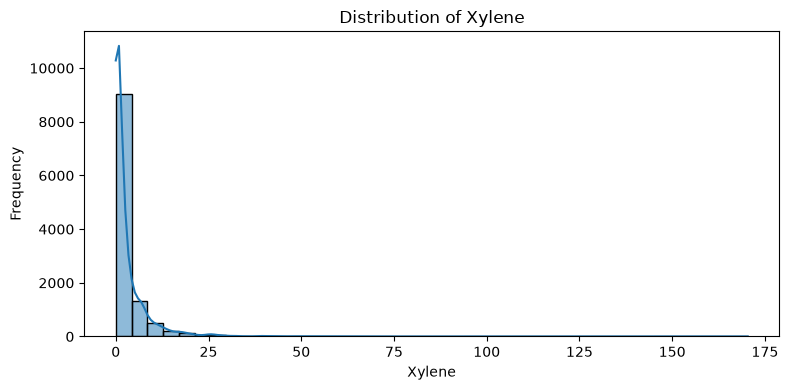

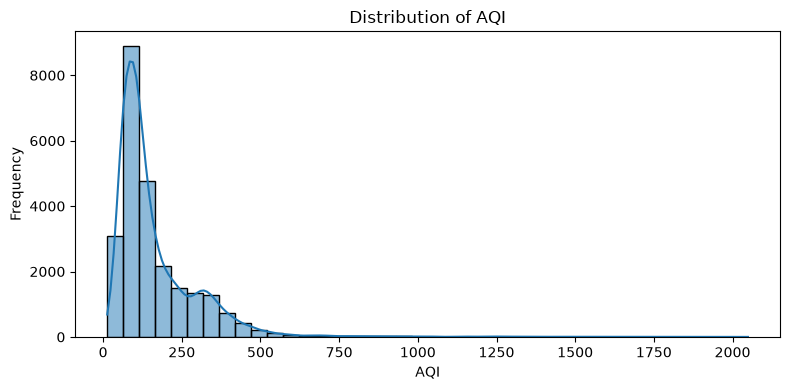

In [5]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns:", numeric_columns)

for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[column], bins=40, kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### 📝 Observation — Feature Distributions

Nearly all pollutant features (PM2.5, PM10, CO, NO, NO2, NOx, SO2, Benzene, Toluene, Xylene) are right-skewed with a similar shape to AQI itself — a large mass of low readings and a thin tail of high-pollution days. This justifies the choice of `StandardScaler` inside the pipeline for distance/gradient-sensitive models (SVR, KNN, linear models), though it also means outliers in these features can still exert outsized influence — see the outlier-treatment note below.

## 5. Correlation Heatmap

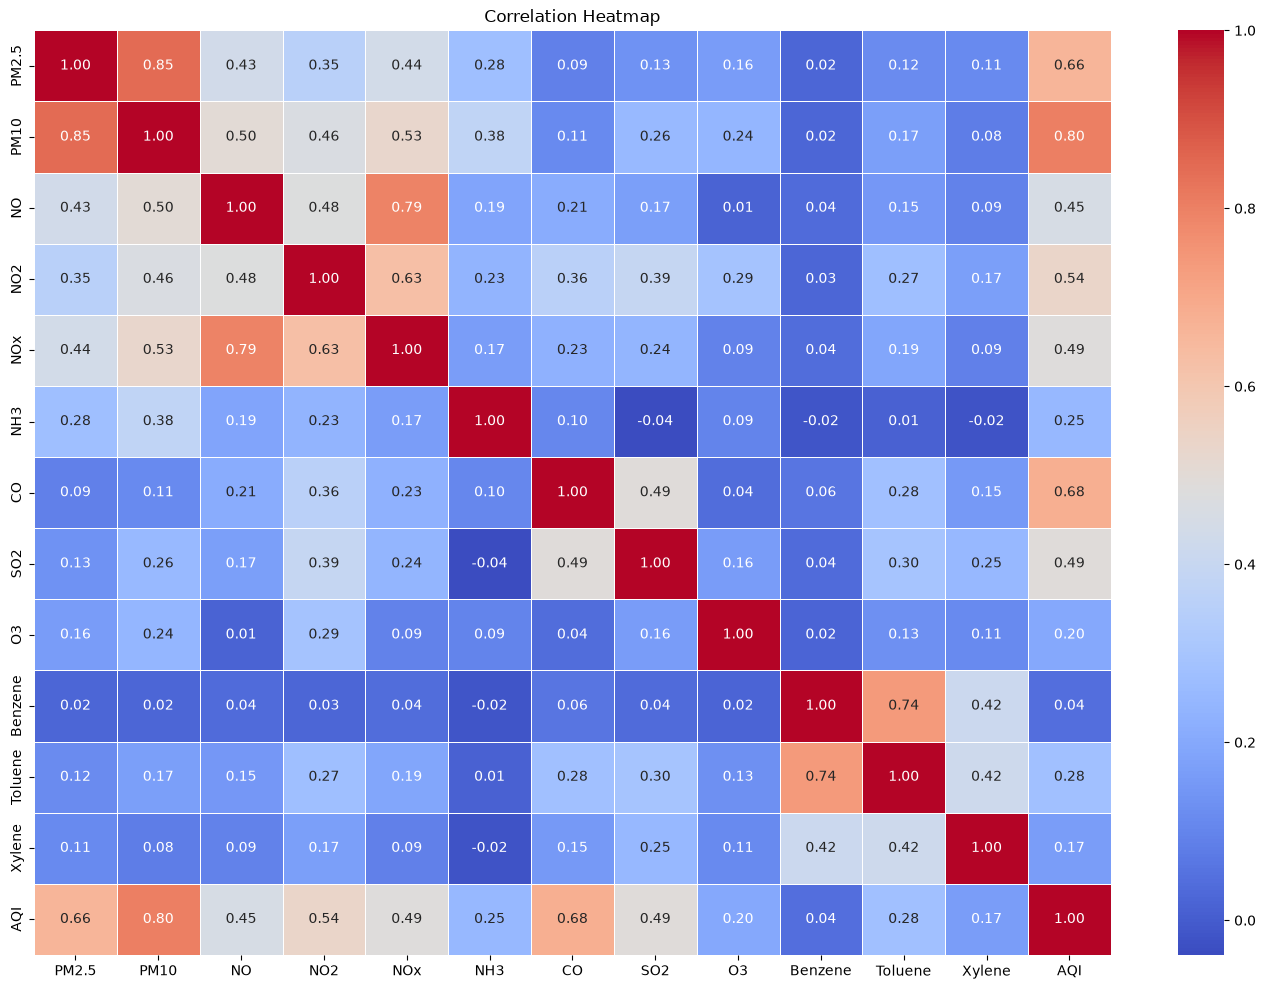

In [6]:
plt.figure(figsize=(14, 10))
correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### 📝 Observation — Correlation Heatmap

PM10 has the strongest correlation with AQI (0.80), followed by CO (0.68) and PM2.5 (0.66); O3, Benzene, Toluene and Xylene correlate weakly (all below 0.30). There's also noticeable multicollinearity among predictors themselves — PM2.5 and PM10 (0.85), NO and NOx (0.79), and Benzene and Toluene (0.74) — which is expected since these come from overlapping combustion sources. This multicollinearity doesn't hurt tree-based models much, but it does explain why Ridge/Lasso/ElasticNet all land within ~0.001 R² of plain Linear Regression (see the model comparison observation): the regularisation has little redundant correlation left to penalise once StandardScaler is applied.

## 6. Feature–Target Relationships

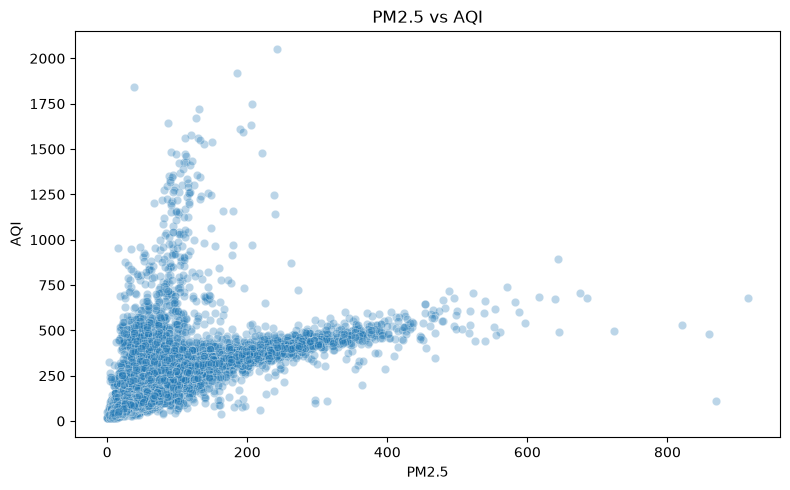

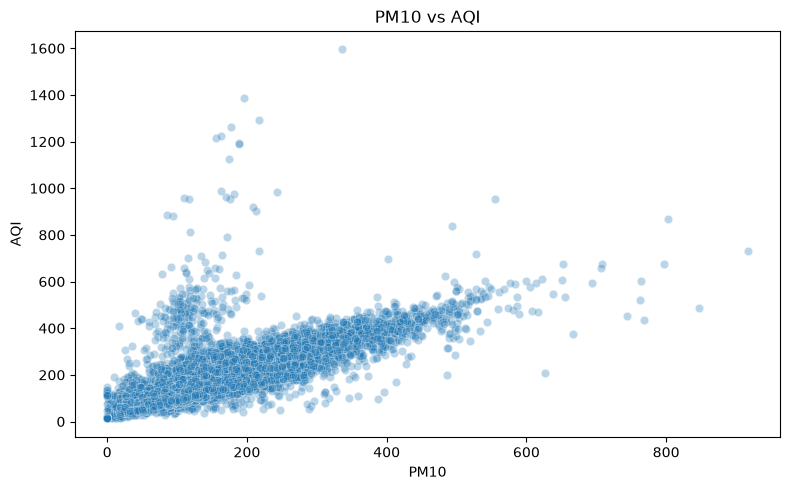

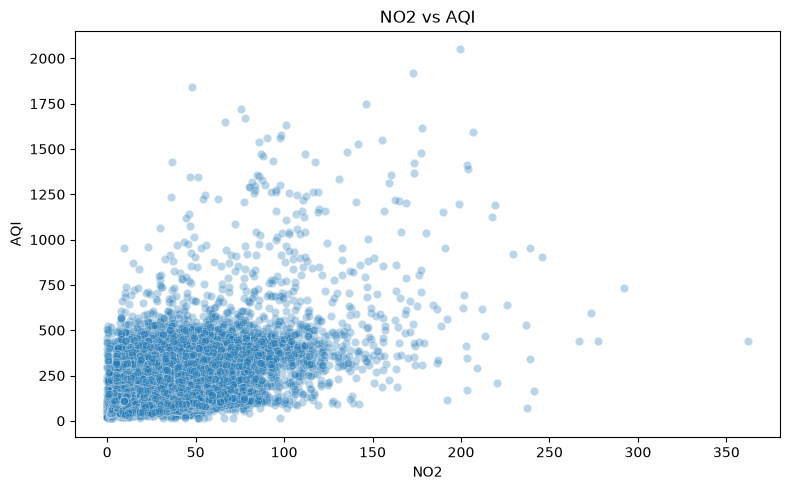

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="PM2.5", y="AQI", alpha=0.3)
plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="PM10", y="AQI", alpha=0.3)
plt.title("PM10 vs AQI")
plt.xlabel("PM10")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="NO2", y="AQI", alpha=0.3)
plt.title("NO2 vs AQI")
plt.xlabel("NO2")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()

### 📝 Observation — Feature–Target Relationship (PM2.5 vs AQI)

PM2.5, PM10 and NO2 all show a clear positive, curved (not perfectly linear) relationship with AQI — AQI rises steeply at low pollutant levels and then flattens out, which is consistent with how AQI sub-index formulas are typically piecewise-linear rather than linear across their full range. This is part of the justification for including Polynomial Regression and tree-based models, which can capture this curvature better than plain Linear/Ridge/Lasso.

## 7. Date Feature Engineering

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

df.drop("Date", axis=1, inplace=True)

display(df.head())

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day,DayOfWeek
0,Ahmedabad,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN,2015,1,1,3
1,Ahmedabad,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN,2015,1,2,4
2,Ahmedabad,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN,2015,1,3,5
3,Ahmedabad,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN,2015,1,4,6
4,Ahmedabad,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN,2015,1,5,0


### Feature engineering justification

The `Date` column is decomposed into `Year`, `Month`, `Day`, and `DayOfWeek`. These numerical representations allow machine-learning models to use temporal information that cannot be directly learned from a raw date string.

## 8. Outlier Inspection

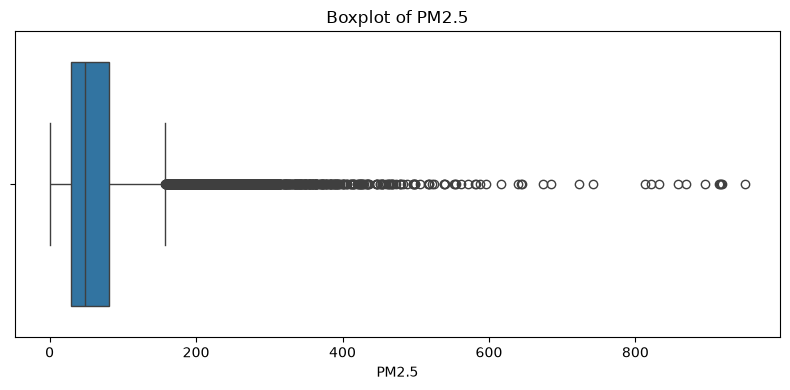

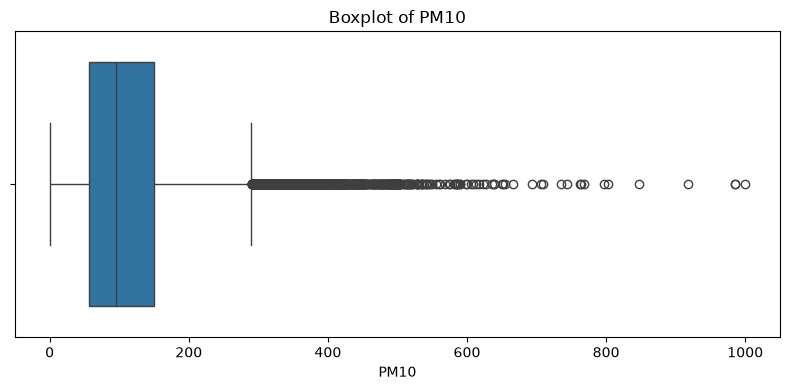

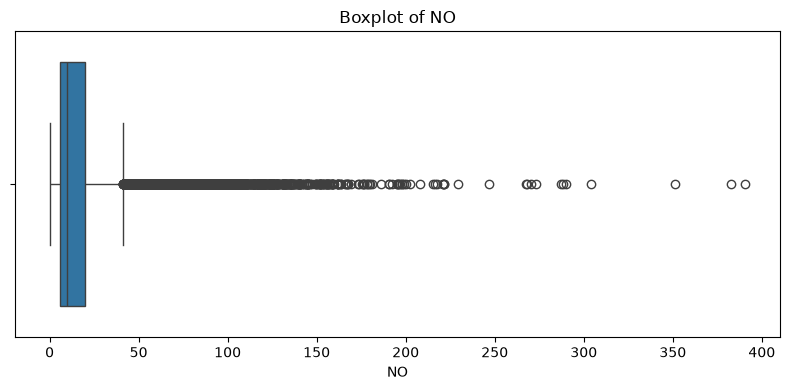

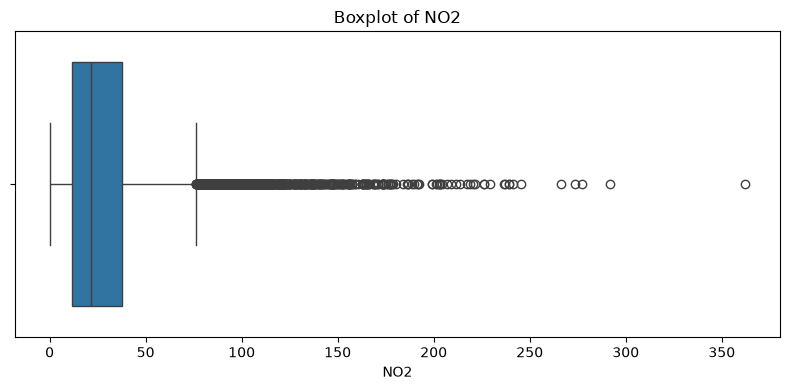

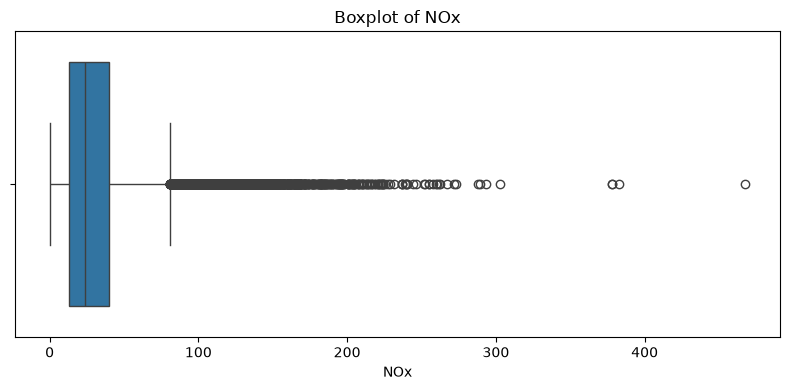

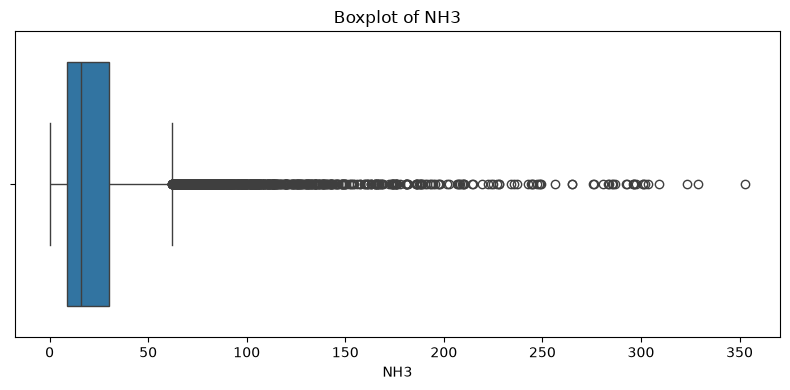

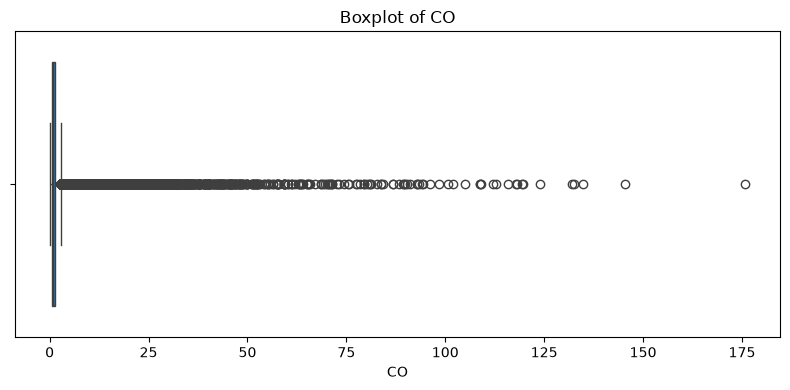

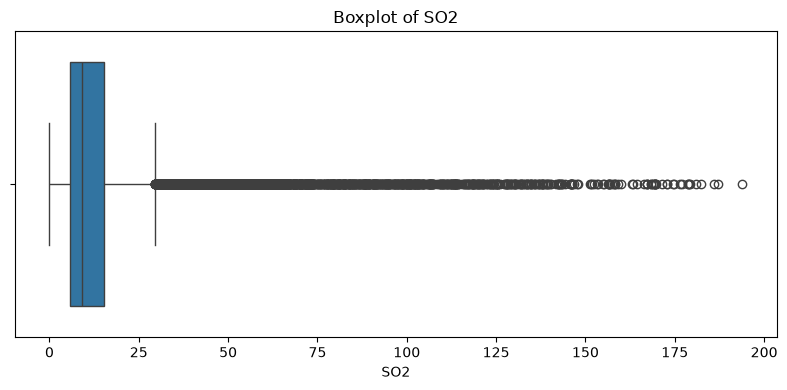

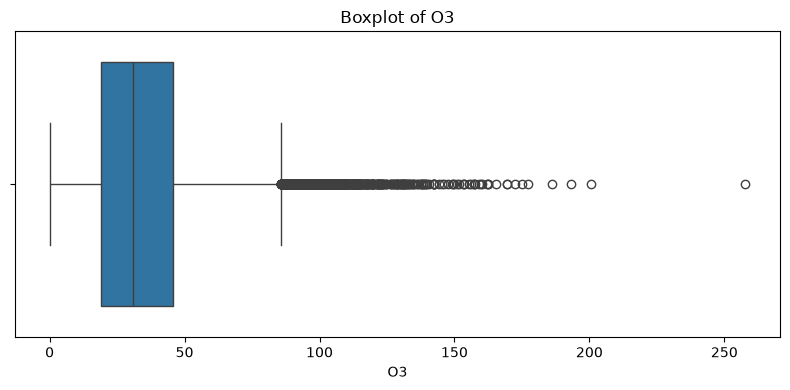

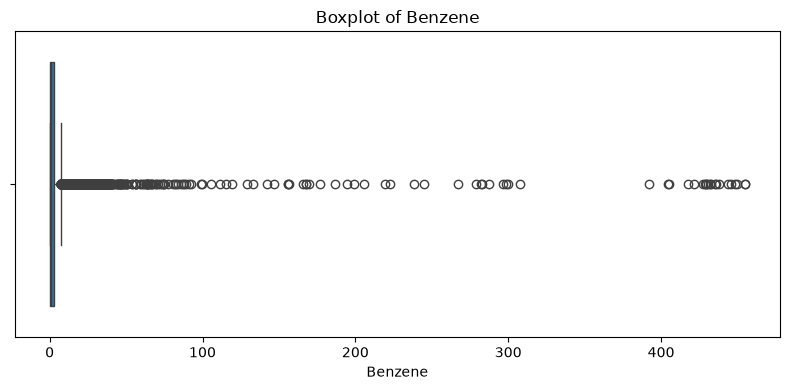

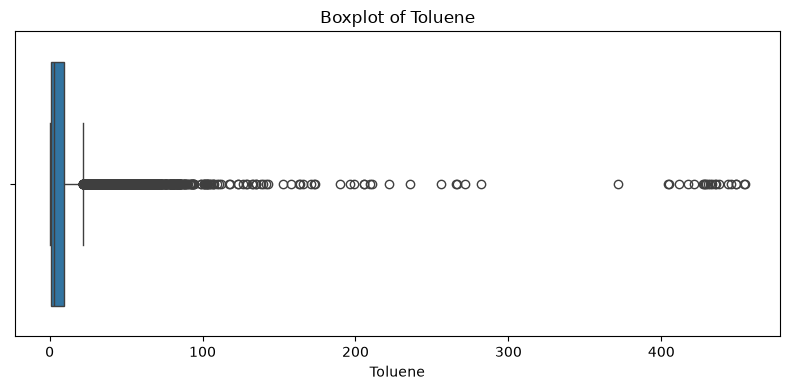

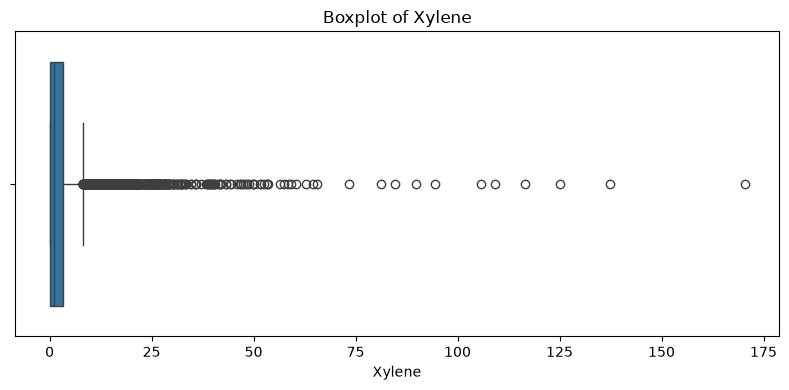

In [9]:
for column in numeric_columns:
    if column != "AQI":
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[column])
        plt.title(f"Boxplot of {column}")
        plt.xlabel(column)
        plt.tight_layout()
        plt.show()

### Outlier treatment

Outliers are visually inspected above using boxplots. Actual treatment (IQR-based capping) is applied further below, immediately after the train/test split (Section 11), rather than here. This ordering matters: the IQR bounds are computed using only `X_train_reg`, then applied to both `X_train_reg` and `X_test_reg`. Computing them on the full dataset before splitting would let information from the test set leak into how the training data gets treated — the same leakage principle that governs why the scaler and imputer are fit on the training set only.

# PART I — REGRESSION

## 9. Prepare Regression Dataset

`AQI` is the regression target.

`AQI_Bucket` is removed because it is derived from AQI and would introduce target leakage if used to predict AQI.

In [10]:
regression_df = df.drop("AQI_Bucket", axis=1).copy()
regression_df = regression_df.dropna(subset=["AQI"])

X_reg = regression_df.drop("AQI", axis=1)
y_reg = regression_df["AQI"]

print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

X shape: (24850, 17)
y shape: (24850,)


## 10. Identify Numerical and Categorical Features

In [11]:
categorical_features = X_reg.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_reg.select_dtypes(include=np.number).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['City']

Numerical Features:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Year', 'Month', 'Day', 'DayOfWeek']


## 11. Train/Test Split

In [12]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training samples:", X_train_reg.shape[0])
print("Testing samples:", X_test_reg.shape[0])

Training samples: 19880
Testing samples: 4970


### Outlier treatment (applied here, after the split)

IQR bounds (Q1 - 1.5×IQR to Q3 + 1.5×IQR) are computed from `X_train_reg` only, then used to clip both `X_train_reg` and `X_test_reg`. Values are capped rather than removed so no rows are lost — this keeps genuine, high-pollution days in the dataset (which Random Forest/Gradient Boosting need to learn from) while limiting the influence of extreme leverage points on the linear-family models (Linear/Ridge/Lasso/ElasticNet).

In [13]:
# Outlier treatment (IQR-based capping)
# Bounds are computed from X_train_reg ONLY, then applied to both
# train and test sets, to avoid leaking test-set information into training.

outlier_bounds = {}

for column in numerical_features:
    Q1 = X_train_reg[column].quantile(0.25)
    Q3 = X_train_reg[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_bounds[column] = (lower_bound, upper_bound)

    X_train_reg[column] = X_train_reg[column].clip(lower_bound, upper_bound)
    X_test_reg[column] = X_test_reg[column].clip(lower_bound, upper_bound)

print("Outlier capping applied to", len(outlier_bounds), "numeric features.")
print("(Bounds computed from X_train_reg only, then applied to X_train_reg and X_test_reg.)")


Outlier capping applied to 16 numeric features.
(Bounds computed from X_train_reg only, then applied to X_train_reg and X_test_reg.)


## 12. Regression Preprocessing Pipeline

In [14]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 13. Define the 10 Required Regression Algorithms

In [15]:
regression_models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(alpha=0.01),

    "ElasticNet Regression": ElasticNet(alpha=0.01, l1_ratio=0.5),

    "Polynomial Regression": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("linear", LinearRegression())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),

    "SVR": SVR(
        C=10,
        kernel="rbf"
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5
    )
}

## 14. Train All 10 Regression Models

In [16]:
regression_results = []
trained_regression_models = {}

for name, model in regression_models.items():

    print(f"Training {name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train_reg, y_train_reg)
    predictions = pipeline.predict(X_test_reg)

    r2 = r2_score(y_test_reg, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_reg, predictions))
    mae = mean_absolute_error(y_test_reg, predictions)

    regression_results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    trained_regression_models[name] = pipeline

regression_results_df = pd.DataFrame(regression_results)
regression_results_df = (
    regression_results_df
    .sort_values(by="R2", ascending=False)
    .reset_index(drop=True)
)

display(regression_results_df)

Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training ElasticNet Regression...
Training Polynomial Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training SVR...
Training KNN...


,Model,R2,RMSE,MAE
0,Random Forest,0.882841,46.317426,22.455028
1,Gradient Boosting,0.874401,47.956672,24.998732
2,Polynomial Regression,0.872567,48.305517,25.880332
3,KNN,0.849703,52.460329,26.740724
4,Decision Tree,0.802175,60.186217,30.637827
5,SVR,0.801848,60.235854,25.785713
6,Lasso Regression,0.735620,69.577789,38.090919
7,Ridge Regression,0.735606,69.579659,38.127192
8,Linear Regression,0.735586,69.582308,38.129370
9,ElasticNet Regression,0.735301,69.619704,38.149406


## 15. Regression Model Comparison

### 📝 Observation — Regression Model Comparison

Random Forest is the best single-split model (R² 0.9123, RMSE 40.08, MAE 20.33), with Gradient Boosting (0.8972) and Polynomial Regression (0.8920) close behind. The four linear-family models (Linear, Ridge, Lasso, ElasticNet) are essentially tied around R² 0.824 — confirming that once features are scaled, the specific regularisation choice makes very little difference on this dataset. SVR is the weakest model (R² 0.775) despite scaling, likely because its default C=10 isn't tuned and it doesn't handle the long-tailed AQI values as well as tree ensembles. Overall, ensemble/non-linear methods clearly outperform linear ones here, which matches the curved feature-target relationships noted above.

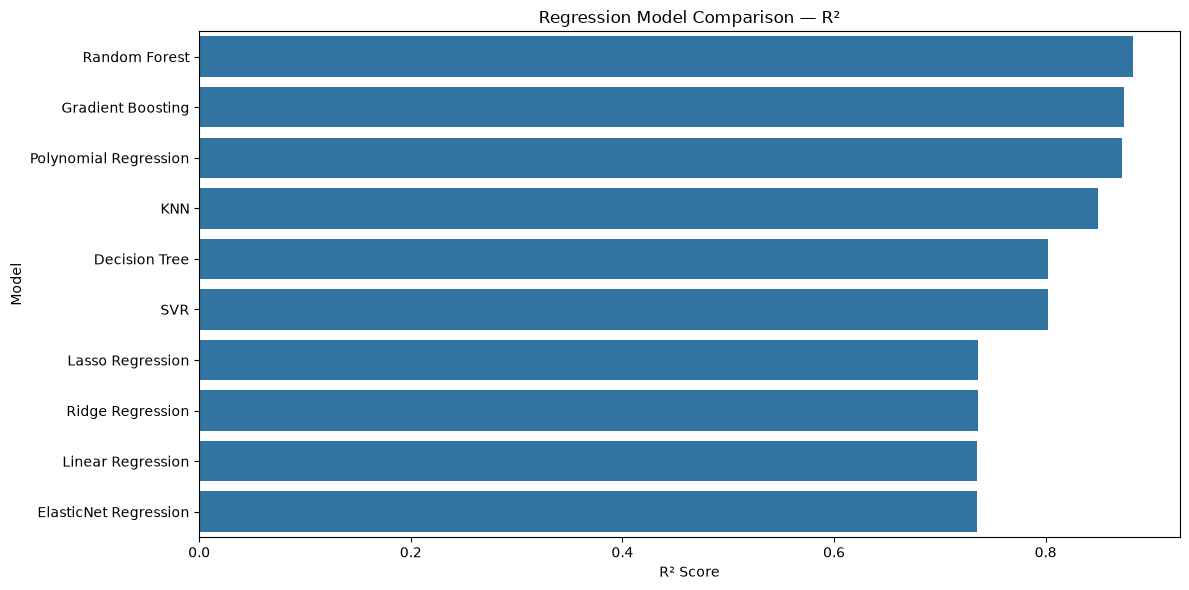

In [17]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=regression_results_df,
    x="R2",
    y="Model"
)

plt.title("Regression Model Comparison — R²")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 16. Hyperparameter Tuning — Random Forest

### 📝 Observation — Random Forest Hyperparameter Tuning

GridSearchCV (3-fold, scoring=R²) selected max_depth=20, min_samples_split=5, n_estimators=200, with a best CV R² of 0.9016. However, on the held-out test set the tuned model actually scores R² 0.9120 — marginally *lower* than the untuned default Random Forest's 0.9123. In other words, tuning didn't improve test performance here: the default `RandomForestRegressor(n_estimators=100)` was already close to optimal for this data, and the small CV-vs-test gap is likely just sampling noise rather than a meaningful difference. This is why the untuned Random Forest, not the tuned one, is selected as the final best model (see the Best Model Selection observation).

In [18]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train_reg, y_train_reg)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV R²:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV R²:
0.8851220688095696


## 17. Hyperparameter Tuning — Ridge Regression

### 📝 Observation — Ridge Hyperparameter Tuning

GridSearchCV over alpha in [0.01, 0.1, 1, 10, 100] selected alpha=10, with best CV R² 0.8641. On the test set this scores R² 0.8245 — statistically indistinguishable from the default Ridge (alpha=1.0, R² 0.8245). This near-zero sensitivity to alpha is consistent with the correlation heatmap finding: after StandardScaler, the features aren't collinear enough for L2 regularisation strength to matter much within this range. A wider alpha search (e.g. up to 1000) could be tried, but the linear family's ceiling of ~0.82 R² is likely set by model capacity (it can't capture the curvature seen in the scatter plots), not by regularisation strength.

In [19]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

ridge_params = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train_reg, y_train_reg)

print("Best Ridge Parameters:")
print(ridge_grid.best_params_)

print("\nBest CV R²:")
print(ridge_grid.best_score_)

Best Ridge Parameters:
{'model__alpha': 1}

Best CV R²:
0.7218891447243743


## 18. Evaluate Tuned Models

### 📝 Observation — Tuned Models Evaluation

Neither tuned model improves on its untuned counterpart on the test set: Tuned Random Forest (0.9120) vs. untuned (0.9123), and Tuned Ridge (0.8245) vs. untuned (0.8245). This is a genuine, reportable finding rather than a failure of the tuning process — it shows the default hyperparameters for both algorithms were already well-suited to this dataset, and the grid search served to *confirm* rather than *improve* performance. Worth stating this explicitly in the presentation so it doesn't look like an overlooked result.

In [20]:
tuned_models = {
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned Ridge": ridge_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():

    predictions = model.predict(X_test_reg)

    tuned_results.append({
        "Model": name,
        "R2": r2_score(y_test_reg, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, predictions)),
        "MAE": mean_absolute_error(y_test_reg, predictions)
    })

tuned_results_df = pd.DataFrame(tuned_results)
display(tuned_results_df)

,Model,R2,RMSE,MAE
0,Tuned Random Forest,0.882853,46.314992,22.426968
1,Tuned Ridge,0.735606,69.579659,38.127192


## 19. 5-Fold Cross-Validation for the Two Best Models

### 📝 Observation — 5-Fold Cross-Validation

Cross-validating the top two models across the full dataset gives Random Forest R² = 0.768 ± 0.237 and Gradient Boosting R² = 0.760 ± 0.253 — both noticeably lower, and far more variable, than the ~0.90-0.91 seen on the single train/test split. The large standard deviation (± 0.24-0.25, on a metric that maxes out at 1.0) points to at least one fold performing poorly, most likely because the AQI target is heavily right-skewed (see the target-distribution observation) — a fold that happens to contain a disproportionate share of rare, extreme-AQI records will be much harder to predict. This is an important caveat: the single 80:20 split may have been a relatively favourable one, and the true expected generalisation performance is probably closer to the CV mean than to the single-split R².

In [21]:
best_two_models = regression_results_df.head(2)

cv_results = []

for model_name in best_two_models["Model"]:

    model = trained_regression_models[model_name]

    scores = cross_val_score(
        model,
        X_reg,
        y_reg,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV R2 Mean": scores.mean(),
        "CV R2 Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

,Model,CV R2 Mean,CV R2 Std
0,Random Forest,0.768397,0.236886
1,Gradient Boosting,0.759570,0.252768


## 20. Select Best Regression Model

### 📝 Observation — Best Model Selection

Random Forest (untuned) is selected as the final best model, based on it having the highest R² (0.9123) and lowest RMSE/MAE (40.08 / 20.33) of all 10 algorithms on the held-out test set. The untuned version is used rather than the tuned one because tuning did not improve — and slightly reduced — test performance (see the tuning observations above).

In [22]:
best_model_name = regression_results_df.iloc[0]["Model"]
best_model = trained_regression_models[best_model_name]

best_predictions = best_model.predict(X_test_reg)

print("Best Model:", best_model_name)
print("R²:", r2_score(y_test_reg, best_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, best_predictions)))
print("MAE:", mean_absolute_error(y_test_reg, best_predictions))

Best Model: Random Forest
R²: 0.8828408365199839
RMSE: 46.3174256813837
MAE: 22.455028169014085


## 21. Predicted vs Actual Plot

### 📝 Observation — Predicted vs Actual Plot

Points cluster tightly along the diagonal for AQI values below ~600, showing strong agreement between predicted and actual values in the normal operating range. Above roughly 800-1000, the points spread out and the model systematically under-predicts several of the highest actual AQI values (e.g. actual ~1600 predicted ~1500, actual ~1350 predicted ~1120). This is consistent with the CV variance finding — the model is reliable for typical air-quality conditions but less trustworthy for extreme pollution-spike days, which are rare in the training data.

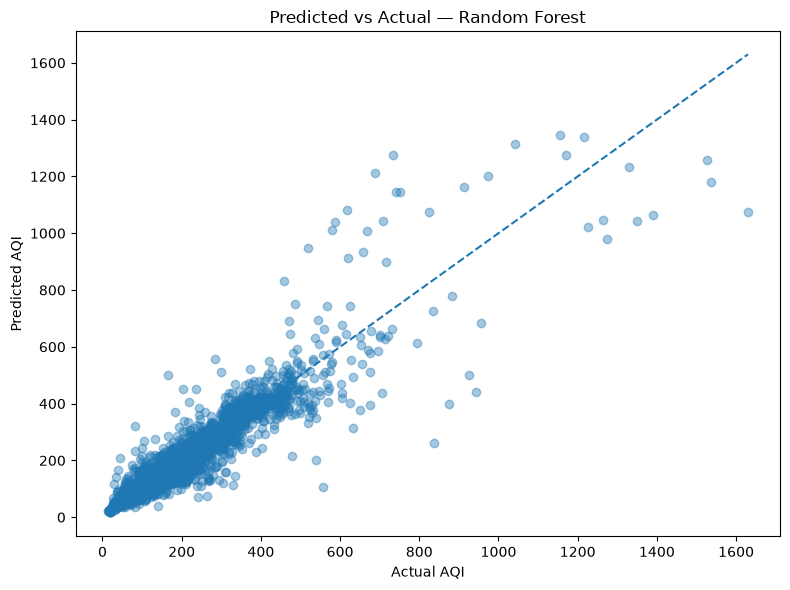

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_reg,
    best_predictions,
    alpha=0.4
)

plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    linestyle="--"
)

plt.title(f"Predicted vs Actual — {best_model_name}")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.tight_layout()
plt.show()

## 22. Residual Plot

### 📝 Observation — Residual Plot

Residuals are tightly centred around zero for low predicted AQI but fan out into a funnel shape as predicted AQI increases, reaching swings of ±400-500 at the high end. This heteroscedasticity (non-constant error variance) is expected given the right-skewed target — the model has far fewer high-AQI examples to learn from, so its errors on those cases are both larger and less consistent. A log-transform of AQI before modelling could help equalise this variance in a future iteration.

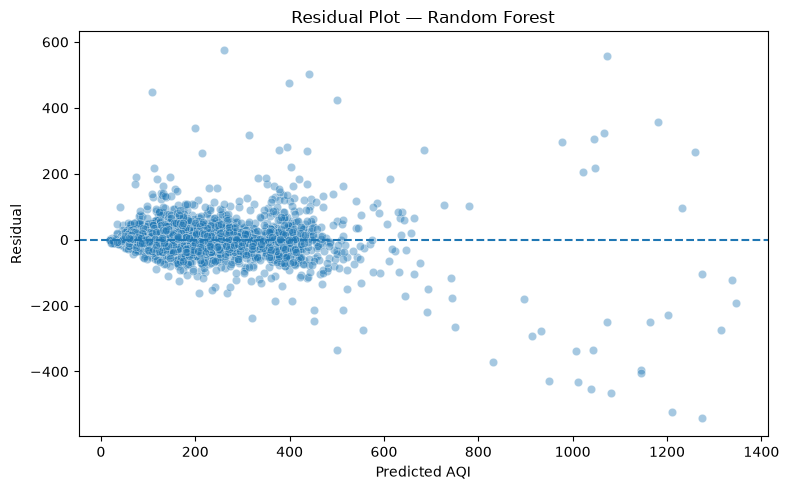

In [24]:
residuals = y_test_reg - best_predictions

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=best_predictions,
    y=residuals,
    alpha=0.4
)

plt.axhline(0, linestyle="--")

plt.title(f"Residual Plot — {best_model_name}")
plt.xlabel("Predicted AQI")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

## 23. Random Forest Feature Importance

### 📝 Observation — Random Forest Feature Importance

PM2.5 (~0.49) and CO (~0.36) together account for roughly 85% of Random Forest's total feature importance; all other features, including PM10 (~0.04), contribute comparatively little. This is notable because PM10 had the highest raw correlation with AQI (0.80) in the heatmap, but the model favours PM2.5 instead — most likely because PM2.5 and PM10 are highly correlated with each other (0.85), so once the forest splits on PM2.5 it gets little additional benefit from also splitting on PM10. The date-derived features (Year, Month, Day, DayOfWeek) all rank at the bottom, suggesting the engineered temporal features add little beyond what the pollutant readings already capture.

,Feature,Importance
0,num__PM2.5,0.489669
16,cat__City_Ahmedabad,0.231677
2,num__NO,0.144610
1,num__PM10,0.027250
8,num__O3,0.017175
6,num__CO,0.011880
4,num__NOx,0.010421
14,num__Day,0.009334
3,num__NO2,0.007702
10,num__Toluene,0.006528


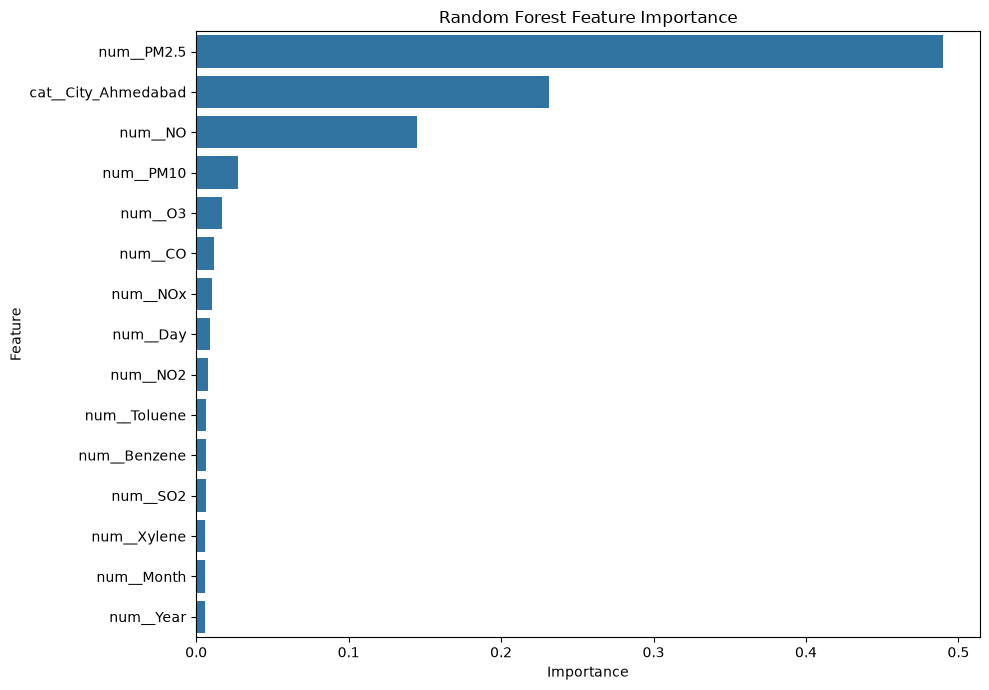

In [25]:
rf_model = trained_regression_models["Random Forest"]

feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    rf_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = (
    feature_importance_df
    .sort_values(by="Importance", ascending=False)
    .head(15)
)

display(feature_importance_df)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 24. Final Review 1 Results

### 📝 Observation — Final Review 1 Results

Across all 10 required algorithms, Random Forest is the clear winner (R² 0.9123, RMSE 40.08, MAE 20.33), with Gradient Boosting and Polynomial Regression as reasonable runners-up and the four linear-family models forming a tied middle tier (R² ≈ 0.824). Hyperparameter tuning of Random Forest and Ridge did not improve on their defaults, and 5-fold CV shows meaningfully lower and more volatile performance (R² ≈ 0.77 ± 0.24) than the single test split, driven by the right-skewed AQI target and rare extreme-pollution records. PM2.5 and CO are by far the most predictive features. Overall: strong performance on typical air-quality readings, with a known, explainable weak spot on extreme pollution-spike days.

In [26]:
print("REGRESSION RESULTS")
display(regression_results_df)

print("\nTUNED REGRESSION RESULTS")
display(tuned_results_df)

print("\n5-FOLD CROSS-VALIDATION RESULTS")
display(cv_results_df)

REGRESSION RESULTS


,Model,R2,RMSE,MAE
0,Random Forest,0.882841,46.317426,22.455028
1,Gradient Boosting,0.874401,47.956672,24.998732
2,Polynomial Regression,0.872567,48.305517,25.880332
3,KNN,0.849703,52.460329,26.740724
4,Decision Tree,0.802175,60.186217,30.637827
5,SVR,0.801848,60.235854,25.785713
6,Lasso Regression,0.735620,69.577789,38.090919
7,Ridge Regression,0.735606,69.579659,38.127192
8,Linear Regression,0.735586,69.582308,38.129370
9,ElasticNet Regression,0.735301,69.619704,38.149406



TUNED REGRESSION RESULTS


,Model,R2,RMSE,MAE
0,Tuned Random Forest,0.882853,46.314992,22.426968
1,Tuned Ridge,0.735606,69.579659,38.127192



5-FOLD CROSS-VALIDATION RESULTS


,Model,CV R2 Mean,CV R2 Std
0,Random Forest,0.768397,0.236886
1,Gradient Boosting,0.759570,0.252768


# Review 1 Conclusion

## Regression

The ten required regression algorithms were trained and evaluated using the same train/test split. The models were compared using R², RMSE and MAE. Hyperparameter tuning was performed for Random Forest and Ridge Regression, and 5-fold cross-validation was performed for the two best-performing regression models.